# Notebook Objectives

In this notebooks, we'll go through the main behavioral analysis results.

Results include:
* ?
* ?

---
# Setup


In [1]:
##% title Imports
import os
import pandas as pd
from sklearn.linear_model import LogisticRegressionCV, RidgeCV, LassoCV, Lasso
from scipy import stats

from popy.io_tools import *
from popy.behavior_data_tools import *
from popy.neural_data_tools import time_normalize_session, scale_neural_data, remove_low_fr_neurons, remove_trunctuated_neurons
from popy.decoding.decoder_tools import *
from popy.plotting.plotting_tools import *
#from popy.plotting.plot_behavior import show_target_selection 
import popy.config as cfg
from popy.plotting.plot_cortical_grid import plot_on_cortical_grid

PATH = cfg.PROJECT_PATH_LOCAL


In [2]:
##% data loading
def load_data_custom(monkey, session, area=None, n_extra_trials=(0, 0)):
    # 1. Behavior data

    # Load behavior data
    behav = load_behavior(monkey, session)
    behav = drop_time_fields(behav)

    # add behav vars to decode
    behav = add_stay_value(behav, reset_on_switch=True)  # add shift value for its decoding
    behav = add_switch_info(behav)  # add switch information for its decoding
    behav = add_history_of_feedback(behav, num_trials=1, one_column=False)

    # 2. Neural data

    # Load neural data
    neural_data = load_neural_data(monkey, session, hz=1000)

    if area is not None:
        # Filter neural data by area
        neural_data = neural_data.sel(unit=neural_data.unit.str.contains(area))

    # remove some units
    neural_data = remove_low_fr_neurons(neural_data, 1, print_usr_msg=True)
    neural_data = remove_trunctuated_neurons(neural_data, mode='remove', delay_limit=10, print_usr_msg=True)

    # process neural data
    neural_data = add_firing_rates(neural_data, drop_spike_trains=True, method='gauss', std=.05)
    neural_data = downsample_time(neural_data, 100)
    neural_data = scale_neural_data(neural_data)
    neural_data = time_normalize_session(neural_data)

    # 3. build neural dataset and merge with behavior
    neural_dataset = build_trial_dataset(neural_data, mode='full_trial', n_extra_trials=(0, 0))
    neural_dataset = merge_behavior(neural_dataset, behav)

    return neural_dataset

In [3]:
# @title Helper Functions

def get_weights_per_area(weights, t=3.5):
    '''
    Get the weights of the PCA components per area
    '''

    # to df, where columns are monkey, session, area, unit, weight
    data_to_df = []
    for unit_temp in weights.unit.values:
        data_to_df.append(
            {'monkey': unit_temp.split('_')[0],
            'session': unit_temp.split('_')[1],
            'area': unit_temp.split('_')[2],
            'unit': "_".join(unit_temp.split('_')[3:]),
            'weight': weights.sel(time=t, unit=unit_temp).values,
            }
        )
    df = pd.DataFrame(data_to_df)

    df['weight_ratio'] =np.abs(df['weight'])/np.sum(np.abs(df['weight']))

    # get best weight per monkey, session, area (drop unit)
    df_abs = df.copy()
    df_abs['weight'] = df_abs['weight'].abs()

    df_best = df_abs.groupby(['monkey', 'session', 'area']).agg({'weight': 'max'}).reset_index()
    df_best = df_best.rename(columns={'weight': 'best_weight'})
    df_best['best_weight_ratio'] = (df_best['best_weight'] / df_abs['weight'].sum()) * 100

    df_sum = df_abs.groupby(['monkey', 'session', 'area']).agg({'weight': 'sum'}).reset_index()
    df_sum = df_sum.rename(columns={'weight': 'sum_weight'})
    df_sum['sum_weight_ratio'] = (df_sum['sum_weight'] / df_abs['weight'].sum()) * 100
    df_best = df_best.merge(df_sum, on=['monkey', 'session', 'area'], how='left')

    df_mean = df_abs.groupby(['monkey', 'session', 'area']).agg({'weight': 'mean'}).reset_index()
    df_mean = df_mean.rename(columns={'weight': 'mean_weight'})
    df_best = df_best.merge(df_mean, on=['monkey', 'session', 'area'], how='left')

    return df_best

def time_resolved_decoder(neural_dataset, t_project=3.5):

    target_vector = neural_dataset['target'].values

    # write back to xarray, preserve the trial and time dimensions and corresponding coordinates
    time_coords = {name: coord for name, coord in neural_dataset.coords.items() if 'time' in coord.dims}
    trial_coords = {name: coord for name, coord in neural_dataset.coords.items() if 'trial_id' in coord.dims}

    # create train and test splits
    clf = LinearRegression()

    projections = []
    score = []
    for fold, target_temp in enumerate(np.unique(target_vector)):
        data_train = neural_dataset.sel(trial_id=neural_dataset.target == target_temp)
        data_test = neural_dataset.sel(trial_id=neural_dataset.target != target_temp)

        ## 1. Fit and score the model

        # get labels of this fold

        # get the firing rates for the current time point
        X_train = data_train.firing_rates.sel(time=t_project, method='nearest').values
        X_test = data_test.firing_rates.sel(time=t_project, method='nearest').values
        y_train = data_train['stay_value'].values
        y_test = data_test['stay_value'].values

        # fit the model
        clf.fit(X_train, y_train)

        # print fitting stats: accuracy
        pred_same = clf.predict(X_train)
        pred_alter = clf.predict(X_test)

        pearson_r_same, p_same = stats.pearsonr(pred_same, y_train)
        pearson_r_alter, p_slter = stats.pearsonr(pred_alter, y_test)
        score.append(pearson_r_alter)

        '''print(f"Fold {target_temp} -> same: pearson r: {pearson_r_same:.2f}")
        print(f"Fold {target_temp} -> alter: pearson r: {pearson_r_alter:.2f}")'''

        #if p_same <= 0.01:
                
        # project the whole dataset to this subspace
        neural_dataset_time = neural_dataset.sel(time=t_project, method='nearest')
        data_projected = np.array([neural_dataset_time.firing_rates.data[trial, :] @ clf.coef_.squeeze() for trial in range(neural_dataset.firing_rates.data.shape[0])])

        # Create a DataArray with the projected data
        data_projected_da = xr.DataArray(data_projected, dims=('trial_id'), coords={**trial_coords})

        # add new dimension: subspace, where the coord is the target_temp
        data_projected_da = data_projected_da.assign_coords(subspace=f'target_{str(int(target_temp))}')

        # add to list
        projections.append(data_projected_da.copy())
            
    # concatenate projected data along a new dimension: subspace
    projected_data = xr.concat(projections, dim='subspace')

    return projected_data, np.array(score).mean()

def add_neural_value_coord(data_projected, neural_dataset):
    V_t = data_projected.sel(time=3.5).values
    V_t_m1 = data_projected.sel(time=-4).values

    data_projected = data_projected.assign_coords(V_t=('trial_id', V_t))
    data_projected = data_projected.assign_coords(V_t_m1=('trial_id', V_t_m1))

    return data_projected

In [4]:
##% Plotting Functions

def plot_decoder_results(results, weights, n_extra_trials):
    fig, axs = plt.subplots(1, 3, figsize=(13, 4))

    ax = axs[0]
    ax.plot(results.time, results)
    ax.axhline(.5, color='k', linestyle='--')
    
    plot_keypoints(ax, n_extra_trials, fontsize=8)
    ax.grid(axis='x')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('R2')
    ax.set_xlabel('Time')
    ax.set_title('R2 score')
    # add colorbar
    ax.set_title('decoder performance (cross val)')

    ax = axs[1]
    # plot bar below
    pbar = ax.imshow(weights.data.T, aspect='auto', cmap='RdBu', extent=[weights.time.min(), weights.time.max(), 0-.5, len(weights.unit)-.5], origin='lower', vmin=-np.max(np.abs(weights.data)*.5), vmax=np.max(np.abs(weights.data)*.5))
    plt.colorbar(pbar, ax=ax, pad=0.005, fraction=.05)
    
    plot_keypoints(ax, n_extra_trials, fontsize=8)
    ax.grid(axis='x', alpha=.5, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Time')
    ax.set_ylabel('Unit')
    ax.set_title('Weights')

    ax = axs[2]
    df_weights = get_weights_per_area(weights, t=3.5)
    plot_on_cortical_grid(df_weights, 'sum_weight_ratio', 
                            bar_title='percentage of weights given by area (%)',
                            ax=ax)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    return fig, axs

def plot_projected_data(data_projected, title, n_extra_trials, xlim=None):
    # project to axis
    h = 9  # in cm
    w = 12  # in cm

    fig, ax = plt.subplots(figsize=(w/2.54, h/2.54))

    time_vector = data_projected.time.values

    unique_fb_sequences = np.sort(np.unique(data_projected.fb_sequence.data))

    # bwr colormap, n=8 sampples RdYlGn
    colors = sns.color_palette("RdYlGn", len(unique_fb_sequences))[::-1]
    alphas = [1-i for i in np.linspace(0, 1, len(unique_fb_sequences))]
    labels = ["[-, -, -]", "[+, -, -]", "[-, +, -]", "[+, +, -]", "[-, -, +]", "[+, -, +]", "[-, +, +]", "[+, +, +]"][::-1]

    full_mean = np.mean(data_projected, axis=0)

    for i, label in enumerate(unique_fb_sequences[::-1]):
        class_mean = np.mean(data_projected.where(data_projected.fb_sequence == label), axis=0)
        ax.plot(time_vector, class_mean - full_mean, color=colors[i], label=labels[i], linewidth=1, alpha=.7)

    # add behav keyboints
    plot_keypoints(ax, n_extra_trials)
    # y grid only
    ax.grid(axis='x', alpha=.5, linestyle='--')
    ax.axhline(0, color='k', linestyle='-', alpha=.5)

    # remove left and top spines
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
    # move legemd outside
    #ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    # save as svg
    ax.set_ylabel('neural value')
    '''if title is not None:
        ax.set_title(title)
    else:
        ax.set_title('Neural value')'''
    
    if xlim is not None:    
        ax.set_xlim(xlim)

    return fig, ax

def green_red_plot(data_projected):
    # distribution of pos and neg feedback along neural value
    fig, axs = plt.subplots(1, 4, figsize=(20, 6))

    V_t = data_projected.V_t.values
    V_t_m1 = data_projected.V_t_m1.values
    R_t_m1 = data_projected.R_1.values

    # get q_t and q_{t-1}
    q_curr = (V_t - np.min(V_t)) / (np.max(V_t) - np.min(V_t)) 
    q_prev = (V_t_m1 - np.min(V_t_m1)) / (np.max(V_t_m1) - np.min(V_t_m1))
    q_diff = q_curr - q_prev
    fb_vector = R_t_m1 
    fb_sequence = data_projected.fb_sequence.values

    ax = axs[0]

    # boxplot of q_curr: x axis is 8 levels of fb_sequence, y axis is q_curr (mean and std and also individual points are shown)
    sns.boxplot(x=fb_sequence, y=q_curr, palette='RdYlGn', ax=ax)
    sns.stripplot(x=fb_sequence, y=q_curr, color='black', size=3, alpha=0.5, ax=ax)

    mean_val = np.mean(q_curr)
    ax.axhline(mean_val, color='k', linestyle='--', label='mean neural value')

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)

    ax.set_xlabel('Feedback sequence')
    ax.set_ylabel('Neural value at trial=t\n $V_t$')
    #ax.set_ylim(0, 1)
    # remove outliers
    ax.set_yticks([0, .5, 1])   
    ax.set_yticklabels([0, .5, 1])
    # legend
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


    ax = axs[1]

    ax.hist(q_curr[fb_vector == 1], color='tab:green', alpha=.5, label='value after fb positive', bins=10)
    ax.hist(q_curr[fb_vector == 0], color='tab:red', alpha=.5, label='value after fb negative', bins=10)

    ax.axvline(mean_val, color='k', linestyle='--', label='mean neural value')
    # plot mean firing rate
    ax.set_xlabel('Neural value at trial=t\n $V_t$')
    #ax.set_xlim(0, 1)
    ax.set_ylabel('Count')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # distribution of change in value for each feedback
    ax = axs[2]

    ax.hist(q_diff[fb_vector == 1], color='tab:green', alpha=.5, label='value after fb positive', bins=10)
    ax.hist(q_diff[fb_vector == 0], color='tab:red', alpha=.5, label='value after fb negative', bins=10)
    # line at 0 and means
    ax.axvline(0, color='k', linestyle='-')
    ax.axvline(np.mean(q_diff[fb_vector == 1]), color='tab:green', linestyle='--', label='mean fb positive')
    ax.axvline(np.mean(q_diff[fb_vector == 0]), color='tab:red', linestyle='--', label='mean fb negative')

    ax.set_xlabel('Change in neural value \n$\Delta V = V_t - V_{t-1}$')
    #ax.set_xlim(-.7, .7)

    ax.set_ylabel('Count')
    # legend below plot
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axs[3]

    # change in value vs RPE
    RPE_neural = fb_vector - q_prev

    # scatter positive and negative RPEs and fit line
    q_prev_temp = q_prev[fb_vector == 1]
    q_diff_temp = q_diff[fb_vector == 1]
    ax.scatter(q_prev[fb_vector == 1], q_diff[fb_vector == 1], color='tab:green', alpha=.5)
    # fit line
    slope, intercept, r_value, p_value, std_err = stats.linregress(q_prev_temp, q_diff_temp)
    fit_line = slope * q_prev_temp + intercept
    ax.plot(q_prev_temp, fit_line, color='tab:green', alpha=.5)

    # scatter negative RPEs
    q_prev_temp = q_prev[fb_vector == 0]
    q_diff_temp = q_diff[fb_vector == 0]
    ax.scatter(q_prev[fb_vector == 0], q_diff[fb_vector == 0], color='tab:red', alpha=.5)
    # fit line
    slope, intercept, r_value, p_value, std_err = stats.linregress(q_prev_temp, q_diff_temp)
    fit_line = slope * q_prev_temp + intercept
    ax.plot(q_prev_temp, fit_line, color='tab:red', alpha=.5)


    # line at 0
    ax.axvline(mean_val, color='k', linestyle='--')
    ax.axhline(0, color='k', linestyle='-')
    # legend
    ax.scatter([], [], color='tab:green', label='fb positive')
    ax.scatter([], [], color='tab:red', label='fb negative')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
    ax.set_xlabel('Neural value at trial t-1\n $V_{t-1}$')
    ax.set_ylabel('Change in neural value \n$\Delta V = V_t - V_{t-1}$')
    #ax.set_ylim(-np.max(np.abs(q_diff))*1.1, np.max(np.abs(q_diff))*1.1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    # both axes from -1 to 1

    plt.tight_layout()

    return fig, axs


---
# Get data

In [5]:
monkey, session, area = 'ka', '210322', 'MCC'

neural_dataset = load_data_custom(monkey, session, area=area)

neural_dataset

Removed 2/26 units with mean firing rate lower than 1 Hz.
removed units: ['MCC_02_01' 'MCC_11_02']
Removed 8/24 units with trunctuated recordings, delay limit: 10 s.
 Invalid units: {'MCC_01_01', 'MCC_16_03', 'MCC_05_01', 'MCC_01_02', 'MCC_03_01', 'MCC_04_01', 'MCC_02_02', 'MCC_05_02'}


<xarray.Dataset>
Dimensions:           (unit: 16, trial_id: 425, time: 750)
Coordinates: (12/20)
  * unit              (unit) object 'MCC_06_01' 'MCC_07_01' ... 'MCC_16_01'
    unit_id_original  (unit) int64 26 28 66 33 32 30 35 ... 46 48 49 53 52 61 58
    channel           (unit) int64 6 7 7 8 8 8 9 10 11 12 12 13 13 14 16 16
    monkey            (unit) object 'ka' 'ka' 'ka' 'ka' ... 'ka' 'ka' 'ka' 'ka'
    session           (unit) object '210322' '210322' ... '210322' '210322'
    area              (unit) object 'MCC' 'MCC' 'MCC' ... 'MCC' 'MCC' 'MCC'
    ...                ...
    stay_value        (trial_id) float64 0.1183 0.06983 ... 0.3101 0.1831
    V0                (trial_id) float64 0.1183 0.1183 0.1183 ... 0.1183 0.1183
    stay_proba        (trial_id) float64 0.5 0.3739 0.3739 ... 0.885 0.6658
    switch            (trial_id) float64 nan 1.0 1.0 0.0 1.0 ... 0.0 0.0 0.0 1.0
    R_1               (trial_id) float64 nan 0.0 0.0 1.0 0.0 ... 1.0 0.0 0.0 0.0
    T_1               (trial_id) float64 nan 2.0 3.0 1.0 1.0 ... 3.0 3.0 3.0 3.0
Data variables:
    firing_rates      (trial_id, unit, time) float64 3.174 -0.8091 ... -0.7246
Attributes:
    bin_size:  0.01

---
# Section 1: Projection to value subspace

## Define the value subspace

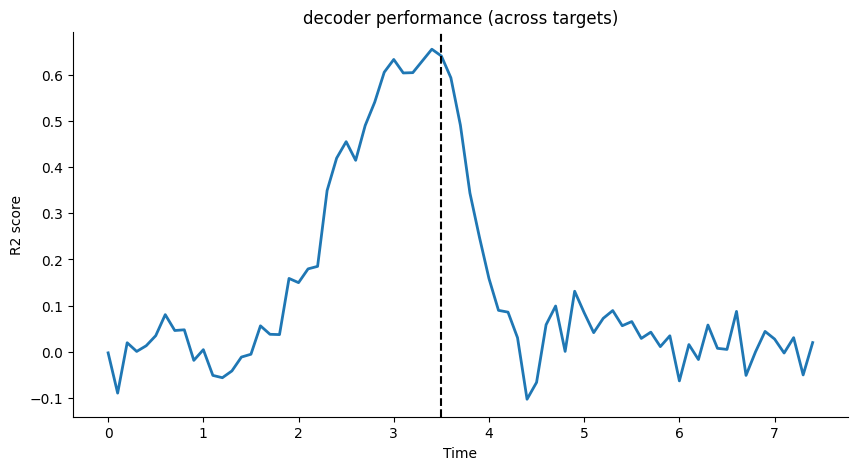

In [6]:
scores = []
for t in neural_dataset.time.values[::10]:
    data_projected, score = time_resolved_decoder(neural_dataset, t_project=t)
    scores.append(score)

# convert to xarray

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(neural_dataset.time[::10], scores, color='tab:blue', linewidth=2)
ax.axvline(3.5, color='k', linestyle='--')
      
ax.set_xlabel('Time')
ax.set_ylabel('R2 score')
ax.set_title('decoder performance (across targets)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show() 

In [7]:
data_projected, score = time_resolved_decoder(neural_dataset, t_project=3.5)

print(f"Score: {score:.2f}")

data_projected 

Score: 0.64


<xarray.DataArray (subspace: 3, trial_id: 425)>
array([[-0.1293688 , -0.33247279, -0.17620928, ...,  0.22692539,
         0.06639815, -0.25509123],
       [-0.09340287, -0.18850273, -0.13558715, ...,  0.19414682,
         0.09480275, -0.1067183 ],
       [ 0.08943077, -0.12813286, -0.06294661, ...,  0.00212467,
         0.10102133, -0.16900295]])
Coordinates:
  * trial_id     (trial_id) int64 0 1 2 3 4 5 6 ... 418 419 420 421 422 423 424
    block_id     (trial_id) int64 0 0 0 0 0 0 0 0 0 0 0 ... 9 9 9 9 9 9 9 9 9 9
    best_target  (trial_id) int64 1 1 1 1 1 1 1 1 1 1 1 ... 3 3 3 3 3 3 3 3 3 3
    target       (trial_id) float64 2.0 3.0 1.0 1.0 3.0 ... 3.0 3.0 3.0 3.0 2.0
    feedback     (trial_id) float64 0.0 0.0 1.0 0.0 0.0 ... 1.0 0.0 0.0 0.0 1.0
    stay_value   (trial_id) float64 0.1183 0.06983 0.06983 ... 0.3101 0.1831
    V0           (trial_id) float64 0.1183 0.1183 0.1183 ... 0.1183 0.1183
    stay_proba   (trial_id) float64 0.5 0.3739 0.3739 ... 0.987 0.885 0.6658
    switch       (trial_id) float64 nan 1.0 1.0 0.0 1.0 ... 0.0 0.0 0.0 0.0 1.0
    R_1          (trial_id) float64 nan 0.0 0.0 1.0 0.0 ... 1.0 1.0 0.0 0.0 0.0
    T_1          (trial_id) float64 nan 2.0 3.0 1.0 1.0 ... 3.0 3.0 3.0 3.0 3.0
  * subspace     (subspace) <U8 'target_1' 'target_2' 'target_3'

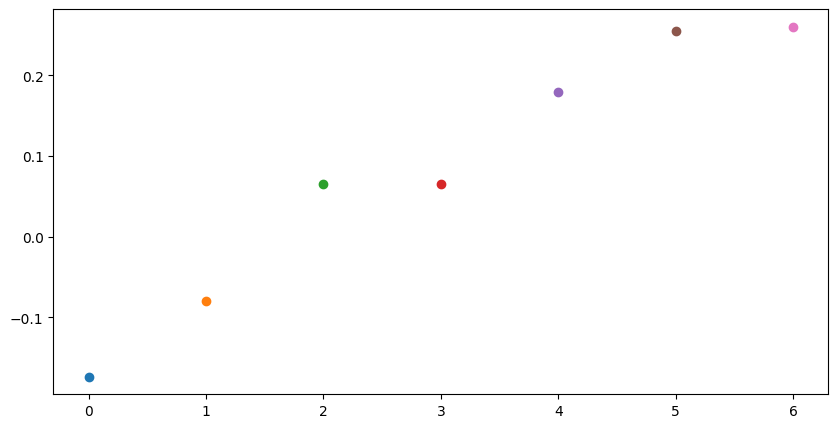

In [8]:
# plot data projected groupped by 4 levels of stay value
fig, ax = plt.subplots(figsize=(10, 5))

bins = np.linspace(0, 1, 8)
for bin in range(len(bins)-1):
    data_temp = data_projected.where((data_projected.stay_value >= bins[bin]) & (data_projected.stay_value < bins[bin+1]) & (data_projected.subspace == 'target_3'), drop=True)
    mean_temp = np.mean(data_temp)
    ax.scatter(bin, mean_temp)

In [9]:
results = []

# loop over the targets
for target in np.unique(data_projected.target.values):

    # get the data projected to the target subspace, where the same target is selected
    data_same = data_projected.sel(subspace=f'target_{str(int(target))}', trial_id=data_projected.target == target)

    trial_ids_same = data_same.trial_id.values  # get the trial ids for the same target
    for trial_id in trial_ids_same:
        if trial_id-1 in trial_ids_same:  # check if trial_id-1 is in the same trials
            # get the diff between t and t-1
            # get the data for the same trials
            V_t = data_same.sel(trial_id=trial_id).values
            V_t_m1 = data_same.sel(trial_id=trial_id-1).values
            dV = V_t - V_t_m1
 
            R_1 = data_same.sel(trial_id=trial_id).R_1.values

            V_behav = data_same.sel(trial_id=trial_id).stay_value.values
            V_behav_m1 = data_same.sel(trial_id=trial_id-1).stay_value.values
            dV_behav = V_behav - V_behav_m1

            results.append({'monkey': monkey, 'session': session, 'trial_id': trial_id, 
                            'target': target, 'type': 'within', 'R_1': int(R_1), 
                            'V_neural': float(V_t), 'V_behav': float(V_behav),
                            'dV': dV, 'dV_behav': dV_behav})

    data_alter = data_projected.sel(subspace=f'target_{str(int(target))}', trial_id=data_projected.target != target)

    trial_ids_alter = data_alter.trial_id.values
    for trial_id in trial_ids_alter:
        if trial_id-1 in trial_ids_alter:
            # get the diff between t and t-1
            # get the data for the same trials
            V_t = data_alter.sel(trial_id=trial_id).values
            V_t_m1 = data_alter.sel(trial_id=trial_id-1).values
            dV = V_t - V_t_m1

            R_1 = data_alter.sel(trial_id=trial_id).R_1.values
            
            V_behav = data_alter.sel(trial_id=trial_id).stay_value.values
            V_behav_m1 = data_alter.sel(trial_id=trial_id-1).stay_value.values
            dV_behav = V_behav - V_behav_m1

            results.append({'monkey': monkey, 'session': session, 'trial_id': trial_id, 
                            'target': target, 'type': 'alter', 'R_1': int(R_1), 
                            'V_neural': float(V_t), 'V_behav': float(V_behav),
                            'dV': dV, 'dV_behav': dV_behav})

# convert to df
results_df = pd.DataFrame(results)
# sort by trial_id
results_df = results_df.sort_values(by=['monkey', 'session', 'trial_id'])
results_df



,monkey,session,trial_id,target,type,R_1,V_neural,V_behav,dV,dV_behav
122,ka,210322,1,1.0,alter,0,-0.332473,0.069825,-0.203104,-0.048449
530,ka,210322,2,2.0,alter,0,-0.135587,0.069825,0.052916,0.000000
0,ka,210322,3,1.0,within,1,-0.051884,0.479459,0.124326,0.409634
531,ka,210322,3,2.0,alter,1,-0.074309,0.479459,0.061278,0.409634
909,ka,210322,3,3.0,alter,1,0.063128,0.479459,0.126075,0.409634
...,...,...,...,...,...,...,...,...,...,...
907,ka,210322,422,3.0,within,0,0.002125,0.525286,-0.396370,-0.364477
396,ka,210322,423,1.0,alter,0,0.066398,0.310111,-0.160527,-0.215175
785,ka,210322,423,2.0,alter,0,0.094803,0.310111,-0.099344,-0.215175
908,ka,210322,423,3.0,within,0,0.101021,0.310111,0.098897,-0.215175


In [10]:
print(f'correlation of V_neural and V_behav: {stats.pearsonr(results_df.V_neural, results_df.V_behav)[0]:.2f}, p-value: {stats.pearsonr(results_df.V_neural, results_df.V_behav)[1]:.2f}')
print(f'correlation of V_neural and V_behav for same trials: {stats.pearsonr(results_df.V_neural[results_df.type == "within"], results_df.V_behav[results_df.type == "within"])[0]:.2f}, p-value: {stats.pearsonr(results_df.V_neural[results_df.type == "within"], results_df.V_behav[results_df.type == "within"])[1]:.2f}')
print(f'correlation of V_neural and V_behav for alter trials: {stats.pearsonr(results_df.V_neural[results_df.type == "alter"], results_df.V_behav[results_df.type == "alter"])[0]:.2f}, p-value: {stats.pearsonr(results_df.V_neural[results_df.type == "alter"], results_df.V_behav[results_df.type == "alter"])[1]:.2f}')

print(f'correlation of dV and dV_behav: {stats.pearsonr(results_df.dV, results_df.dV_behav)[0]:.2f}, p-value: {stats.pearsonr(results_df.dV, results_df.dV_behav)[1]:.2f}')
print(f'correlation of dV and dV_behav for same trials: {stats.pearsonr(results_df.dV[results_df.type == "within"], results_df.dV_behav[results_df.type == "within"])[0]:.2f}, p-value: {stats.pearsonr(results_df.dV[results_df.type == "within"], results_df.dV_behav[results_df.type == "within"])[1]:.2f}')
print(f'correlation of dV and dV_behav for alter trials: {stats.pearsonr(results_df.dV[results_df.type == "alter"], results_df.dV_behav[results_df.type == "alter"])[0]:.2f}, p-value: {stats.pearsonr(results_df.dV[results_df.type == "alter"], results_df.dV_behav[results_df.type == "alter"])[1]:.2f}')

correlation of V_neural and V_behav: 0.59, p-value: 0.00
correlation of V_neural and V_behav for same trials: 0.67, p-value: 0.00
correlation of V_neural and V_behav for alter trials: 0.57, p-value: 0.00
correlation of dV and dV_behav: 0.52, p-value: 0.00
correlation of dV and dV_behav for same trials: 0.60, p-value: 0.00
correlation of dV and dV_behav for alter trials: 0.49, p-value: 0.00


In [11]:
results_df.loc[results_df['type'] == 'within']

,monkey,session,trial_id,target,type,R_1,V_neural,V_behav,dV,dV_behav
0,ka,210322,3,1.0,within,1,-0.051884,0.479459,0.124326,0.409634
398,ka,210322,6,2.0,within,1,0.021540,0.479459,0.060651,0.409634
399,ka,210322,7,2.0,within,0,-0.015795,0.283056,-0.037335,-0.196402
1,ka,210322,10,1.0,within,1,0.017051,0.479459,0.230869,0.409634
2,ka,210322,11,1.0,within,1,0.191350,0.692690,0.174298,0.213231
...,...,...,...,...,...,...,...,...,...,...
904,ka,210322,419,3.0,within,1,0.168038,0.683710,0.136473,0.219462
905,ka,210322,420,3.0,within,1,0.159271,0.813273,-0.008766,0.129563
906,ka,210322,421,3.0,within,1,0.398495,0.889763,0.239223,0.076490
907,ka,210322,422,3.0,within,0,0.002125,0.525286,-0.396370,-0.364477


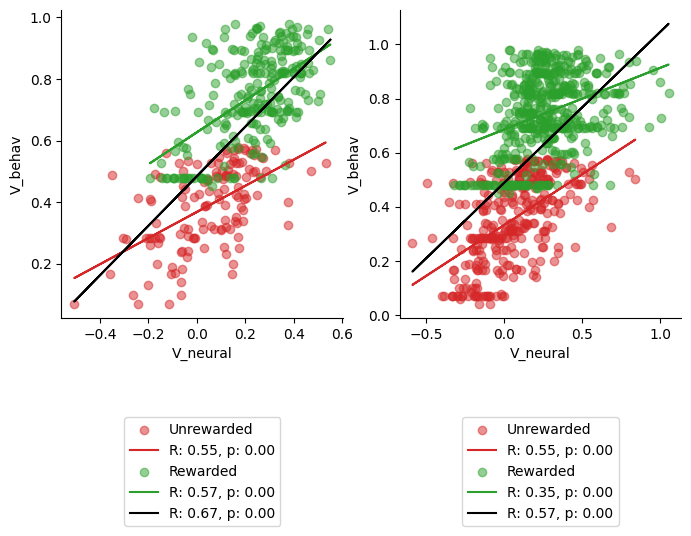

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))


ax = axs[0]
x_neg_within = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 0), 'V_neural']
y_neg_within = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 0), 'V_behav']
ax.scatter(x_neg_within, y_neg_within, color='tab:red', alpha=.5, label='Unrewarded')
line = np.polyfit(x_neg_within, y_neg_within, 1)
corr, pval = stats.pearsonr(x_neg_within, y_neg_within)
ax.plot(x_neg_within, line[0] * x_neg_within + line[1], color='tab:red', alpha=1, label=f'R: {corr:.2f}, p: {pval:.2f}')

x_pos_within = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 1), 'V_neural']
y_pos_within = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 1), 'V_behav']
ax.scatter(x_pos_within, y_pos_within, color='tab:green', alpha=.5, label='Rewarded')
line = np.polyfit(x_pos_within, y_pos_within, 1)
corr, pval = stats.pearsonr(x_pos_within, y_pos_within)
ax.plot(x_pos_within, line[0] * x_pos_within + line[1], color='tab:green', alpha=1, label=f'R: {corr:.2f}, p: {pval:.2f}')


x_all_within = results_df.loc[(results_df['type'] == 'within'), 'V_neural']
y_all_within = results_df.loc[(results_df['type'] == 'within'), 'V_behav']
line = np.polyfit(x_all_within, y_all_within, 1)
corr, pval = stats.pearsonr(x_all_within, y_all_within)
ax.plot(x_all_within, line[0] * x_all_within + line[1], color='black', alpha=1, label=f'R: {corr:.2f}, p: {pval:.2f}')

ax.set_xlabel('V_neural')
ax.set_ylabel('V_behav')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axs[1]
x_neg_alter = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 0), 'V_neural']
y_neg_alter = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 0), 'V_behav']
ax.scatter(x_neg_alter, y_neg_alter, color='tab:red', alpha=.5, label='Unrewarded')
line = np.polyfit(x_neg_alter, y_neg_alter, 1)
corr, pval = stats.pearsonr(x_neg_alter, y_neg_alter)
ax.plot(x_neg_alter, line[0] * x_neg_alter + line[1], color='tab:red', alpha=1, label=f'R: {corr:.2f}, p: {pval:.2f}')

x_pos_alter = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 1), 'V_neural']
y_pos_alter = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 1), 'V_behav']
ax.scatter(x_pos_alter, y_pos_alter, color='tab:green', alpha=.5, label='Rewarded')
line = np.polyfit(x_pos_alter, y_pos_alter, 1)
corr, pval = stats.pearsonr(x_pos_alter, y_pos_alter)
ax.plot(x_pos_alter, line[0] * x_pos_alter + line[1], color='tab:green', alpha=1, label=f'R: {corr:.2f}, p: {pval:.2f}')

x_all_alter = results_df.loc[(results_df['type'] == 'alter'), 'V_neural']
y_all_alter = results_df.loc[(results_df['type'] == 'alter'), 'V_behav']
line = np.polyfit(x_all_alter, y_all_alter, 1)
corr, pval = stats.pearsonr(x_all_alter, y_all_alter)
ax.plot(x_all_alter, line[0] * x_all_alter + line[1], color='black', alpha=1, label=f'R: {corr:.2f}, p: {pval:.2f}')

ax.set_xlabel('V_neural')
ax.set_ylabel('V_behav')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

/var/folders/sc/1kct8wp55hz13v5hhnxrrfy40000gn/T/ipykernel_47399/3845034666.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/sc/1kct8wp55hz13v5hhnxrrfy40000gn/T/ipykernel_47399/3845034666.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/var/folders/sc/1kct8wp55hz13v5hhnxrrfy40000gn/T/ipykernel_47399/3845034666.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Unrewarded', 'Rewarded'])
/var/folders/sc/1kct8wp55hz13v5hhnxrrfy40000gn/T/ipykernel_47399/3845034666.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed 

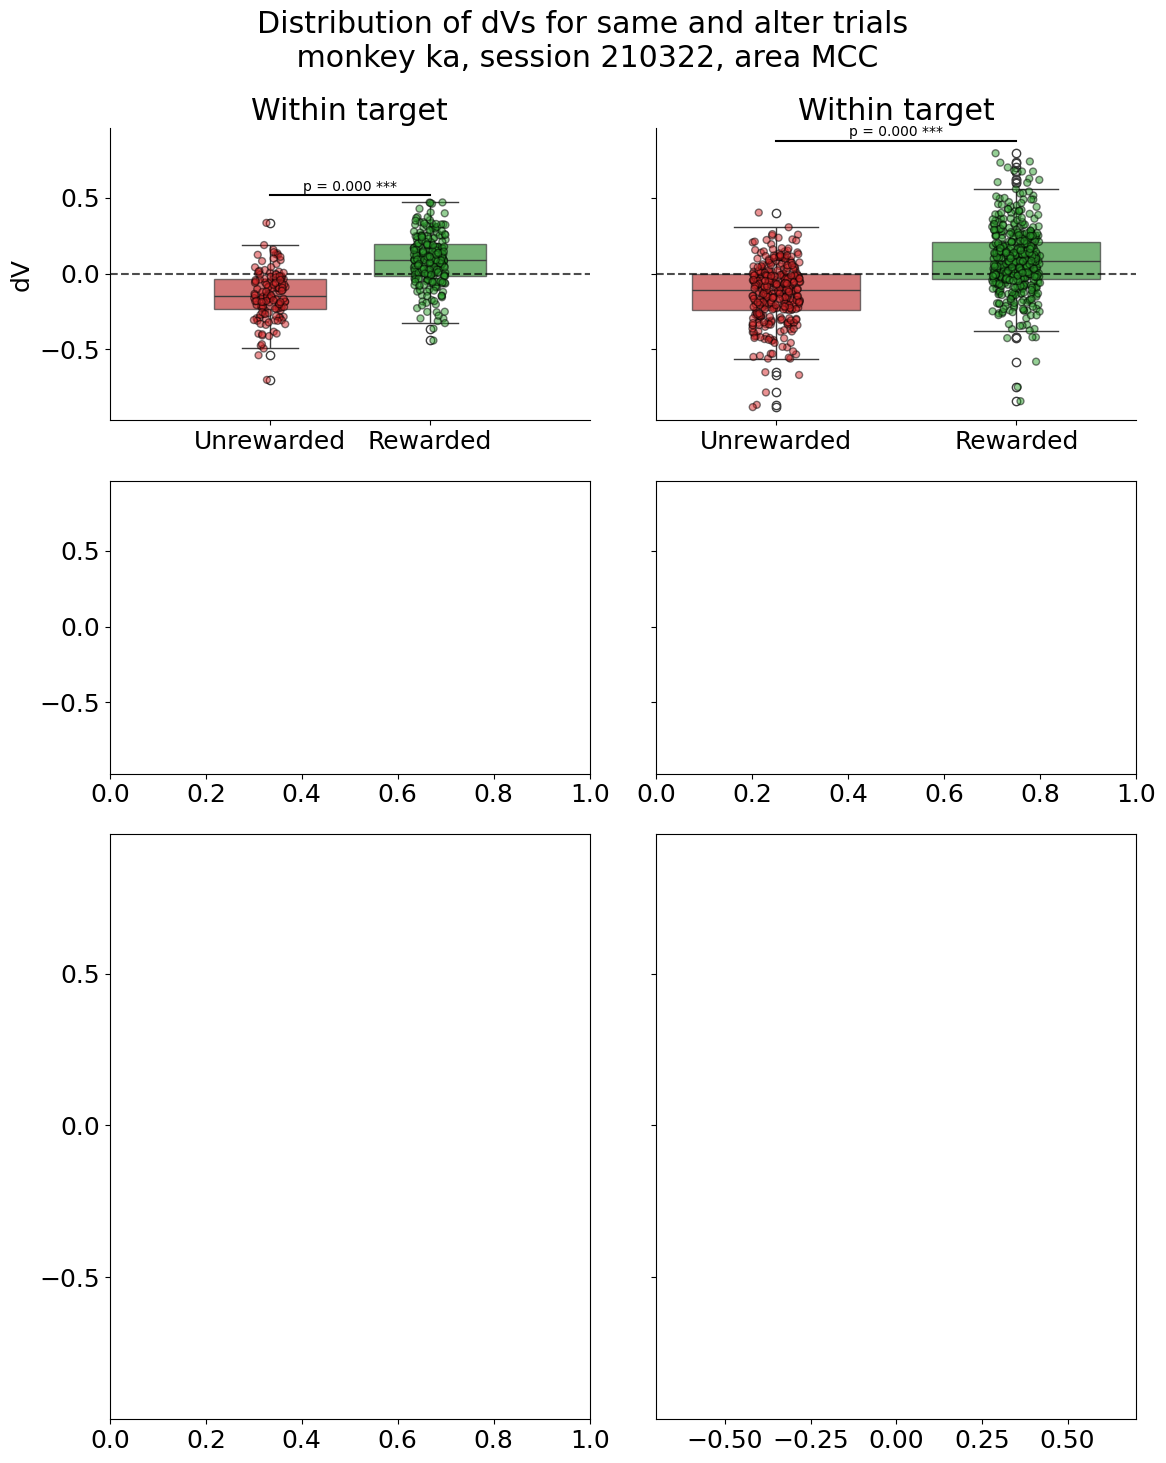

In [28]:
from scipy import stats

# fontsize = 18
plt.rcParams.update({'font.size': 18})

# histogram of deltas: 0 and 1
# top plot is half of the bottom plot in height
fig, axs = plt.subplots(3, 2, figsize=(12, 15), gridspec_kw={'height_ratios': [1, 1, 2]}, sharey=True)
plt.suptitle(f'Distribution of dVs for same and alter trials\n monkey {monkey}, session {session}, area {area}')

bins = np.linspace(-.7, .7, 20)

plt.xlim(-.7, .7)

# plot boxplot: dV for positive and negative feedback (negative on left with boxplot of red, positive on the right with boxplot of green)
ax = axs[0, 0]

# Create the boxplot with narrower bars
sns.boxplot(
    data=results_df.loc[results_df['type'] == 'within'], 
    x='R_1',
    y='dV',
    palette={'0': 'tab:red', '1': 'tab:green'},
    ax=ax,
    width=.7,  # Make bars less wide (default is 0.8)
    boxprops=dict(alpha=0.7)
)

# Add individual data points using stripplot
sns.stripplot(
    data=results_df.loc[results_df['type'] == 'within'], 
    x='R_1',
    y='dV',
    palette={'0': 'tab:red', '1': 'tab:green'},
    edgecolor='black', 
    linewidth=1,
    size=5,
    alpha=0.5,
    ax=ax,
    jitter=True
)

# Perform t-test between the two conditions
neg_values = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 0), 'dV']
pos_values = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 1), 'dV']
t_stat, p_value = stats.ttest_ind(neg_values, pos_values)

# Determine y position for the significance bar (slightly above the highest point)
y_max = max(results_df.loc[results_df['type'] == 'within', 'dV'].max(), 
           neg_values.max(), 
           pos_values.max())
y_pos = y_max + 0.1 * abs(y_max)

# Add significance annotation
if p_value < 0.001:
    significance = '***'
elif p_value < 0.01:
    significance = '**'
elif p_value < 0.05:
    significance = '*'
else:
    significance = 'n.s.'

# Add the bar and text for p-value
ax.plot([0, 1], [y_pos, y_pos], '-k', lw=1.5)
ax.text(0.5, y_pos + 0.02 * abs(y_max), f'p = {p_value:.3f} {significance}', 
        ha='center', va='bottom', fontsize=10)

ax.axhline(0, linestyle='--', alpha=.7, color='black')
ax.set_xticklabels(['Unrewarded', 'Rewarded'])
ax.set_xlabel('')
ax.set_xlim(-1, 2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Within target')


ax = axs[0, 1]

# Create the boxplot with narrower bars
sns.boxplot(
    data=results_df.loc[results_df['type'] == 'alter'], 
    x='R_1',
    y='dV',
    palette={'0': 'tab:red', '1': 'tab:green'},
    ax=ax,
    width=0.7,  # Make bars less wide (default is 0.8)
    boxprops=dict(alpha=0.7)
)

# Add individual data points using stripplot
sns.stripplot(
    data=results_df.loc[results_df['type'] == 'alter'], 
    x='R_1',
    y='dV',
    palette={'0': 'tab:red', '1': 'tab:green'},
    edgecolor='black', 
    linewidth=1,
    size=5,
    alpha=0.5,
    ax=ax,
    jitter=True
)

# Perform t-test between the two conditions
neg_values = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 0), 'dV']
pos_values = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 1), 'dV']
t_stat, p_value = stats.ttest_ind(neg_values, pos_values)

# Determine y position for the significance bar (slightly above the highest point)
y_max = max(results_df.loc[results_df['type'] == 'alter', 'dV'].max(), 
           neg_values.max(), 
           pos_values.max())
y_pos = y_max + 0.1 * abs(y_max)

# Add significance annotation
if p_value < 0.001:
    significance = '***'
elif p_value < 0.01:
    significance = '**'
elif p_value < 0.05:
    significance = '*'
else:
    significance = 'n.s.'

# Add the bar and text for p-value
ax.plot([0, 1], [y_pos, y_pos], '-k', lw=1.5)
ax.text(0.5, y_pos + 0.02 * abs(y_max), f'p = {p_value:.3f} {significance}', 
        ha='center', va='bottom', fontsize=10)

ax.axhline(0, linestyle='--', alpha=.7, color='black')
ax.set_xticklabels(['Unrewarded', 'Rewarded'])
ax.set_xlabel('')
ax.set_xlim(-.5, 1.5)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Within target')

'''
ax = axs[1, 0]
ax.hist(results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 0), 'dV'], color='tab:red', alpha=.5, label='negative feedback', bins=bins)
ax.hist(results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 1), 'dV'], color='tab:green', alpha=.5, label='positive feedback', bins=bins)
# plot means
mean_neg = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 0), 'dV'].mean()
mean_pos = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 1), 'dV'].mean()
ax.axvline(mean_neg, color='tab:red', linestyle='--')
ax.axvline(mean_pos, color='tab:green', linestyle='--')

ax.axvline(0, color='k', linestyle='--')
ax.set_xlabel('$\Delta V = V_t - V_{t-1}$')
ax.set_ylabel('# trials')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Within target')

ax = axs[1, 1]
ax.hist(results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 0), 'dV'], color='tab:red', alpha=.5, label='Rewarded', bins=bins)
ax.hist(results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 1), 'dV'], color='tab:green', alpha=.5, label='Unrewarded', bins=bins)
# plot means
mean_neg = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 0), 'dV'].mean()
mean_pos = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 1), 'dV'].mean()
ax.axvline(mean_neg, color='tab:red', linestyle='--')
ax.axvline(mean_pos, color='tab:green', linestyle='--')
ax.axvline(0, color='k', linestyle='--')
ax.set_xlabel('$\Delta V = V_t - V_{t-1}$')
ax.set_ylabel('# trials')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Across target')

ax = axs[2, 0]
x_neg_within = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 0), 'dV']
y_neg_within = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 0), 'dV_behav']
ax.scatter(x_neg_within, y_neg_within, color='tab:red', alpha=.5, label='Unrewarded')
line = np.polyfit(x_neg_within, y_neg_within, 1)
ax.plot(x_neg_within, line[0] * x_neg_within + line[1], color='tab:red', alpha=1)

x_pos_within = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 1), 'dV']
y_pos_within = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 1), 'dV_behav']
ax.scatter(x_pos_within, y_pos_within, color='tab:green', alpha=.5, label='Rewarded')
line = np.polyfit(x_pos_within, y_pos_within, 1)
ax.plot(x_pos_within, line[0] * x_pos_within + line[1], color='tab:green', alpha=1)

x_all_within = results_df.loc[(results_df['type'] == 'within'), 'dV']
y_all_within = results_df.loc[(results_df['type'] == 'within'), 'dV_behav']
line = np.polyfit(x_all_within, y_all_within, 1)
ax.plot(x_all_within, line[0] * x_all_within + line[1], color='black', alpha=1)

ax.axvline(0, color='k', linestyle='--', alpha=.5)
ax.axhline(0, color='k', linestyle='--', alpha=.5)
ax.set_xlabel('$\Delta V_{neural} = V_t - V_{t-1}$')
ax.set_ylabel('$\Delta V_{behav} = V_t - V_{t-1}$')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axs[2, 1]
x_neg_alter = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 0), 'dV']
y_neg_alter = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 0), 'dV_behav']
ax.scatter(x_neg_alter, y_neg_alter, color='tab:red', alpha=.5, label='Unrewarded')
line = np.polyfit(x_neg_alter, y_neg_alter, 1)
ax.plot(x_neg_alter, line[0] * x_neg_alter + line[1], color='tab:red', alpha=1)

x_pos_alter = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 1), 'dV']
y_pos_alter = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 1), 'dV_behav']
ax.scatter(x_pos_alter, y_pos_alter, color='tab:green', alpha=.5, label='Rewarded')
line = np.polyfit(x_pos_alter, y_pos_alter, 1)
ax.plot(x_pos_alter, line[0] * x_pos_alter + line[1], color='tab:green', alpha=1)

x_all_alter = results_df.loc[(results_df['type'] == 'alter'), 'dV']
y_all_alter = results_df.loc[(results_df['type'] == 'alter'), 'dV_behav']
line = np.polyfit(x_all_alter, y_all_alter, 1)
ax.plot(x_all_alter, line[0] * x_all_alter + line[1], color='black', alpha=1)

ax.axvline(0, color='k', linestyle='--', alpha=.5)
ax.axhline(0, color='k', linestyle='--', alpha=.5)
ax.set_xlabel('$\Delta V_{neural} = V_t - V_{t-1}$')
ax.set_ylabel('$\Delta V_{behav} = V_t - V_{t-1}$')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)'''

plt.tight_layout()

# save svg
plt.savefig('figs/dV_neural_behav.svg', format='svg', bbox_inches='tight')
